# Calcium: reproducing EPW, diagnosing the gap, and closing it with GW

**EPW's conductivity for fcc Ca is far off experiment**: $\sigma = 7.98$ against
$28.99\times10^{6}\,$S/m at 300 K, a factor **3.63**. That size matters, because
3.63 is reachable by effects one can enumerate where an order of magnitude would
demand something qualitative.

This notebook answers three questions in order, and the order is the point:

1. **Does `waw` reproduce EPW at all?** Until two independent codes agree on the
   same inputs, any discrepancy against experiment is unattributable.
2. **If they agree, what is missing from both?** The diagnosis is calorimetric
   and it is falsifiable: Ca's measured $\gamma$ forbids the DFT $N(E_F)$.
3. **Does $GW$ fix it?** The quasiparticle corrections are folded into
   $H(\mathbf R)$ and transport is redone with the electron–phonon vertex held
   fixed.

The answer to (3) is **yes, and it stops being yes if pushed further**. $G_0W_0$
brings $N(E_F)$ onto the value calorimetry demands and $\sigma$ to 0.68 of
experiment; one eigenvalue-self-consistent step raises $\sigma$ further, to 0.845,
while carrying $N(E_F)$ 12% past the target in the wrong direction. An independent
constraint on the electronic structure is what makes those two outcomes
distinguishable.

## 1. waw against EPW on identical inputs

The comparison is done on **EPW's own data**: their Wannier Hamiltonian (`chw`),
their dynamical matrix (`rdw`), their electron–phonon matrix elements
(`qe.epmatwp`, 2.6 GB) and their PBEsol geometry ($a = 5.4538$ Å, the
Alexandria-relaxed value — *not* the experimental 5.588 Å). Only the Boltzmann
solver differs.

**The scattering $\mathbf q$ mesh must be converged independently of the vertex.**
EPW interpolates the vertex to $48^3$; sampling the scattering instead on the 16
irreducible points of the vertex's **native** $6^3$ mesh gives a $\sigma$ too
large by 1.76×. The $\mathbf q$ ladder below is therefore part of the comparison,
not a preliminary to it. The diagnostic that identifies an unconverged
$\mathbf q$ mesh is that $\Omega_p$ **does not move**: refining $\mathbf q$
changes the scattering, not the Fermi-surface velocities.

In [1]:
import sys, pathlib, warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
warnings.simplefilter('ignore')

RUN = REPO / 'workflows' / 'notebooks' / 'runs' / 'ca_gw_nb'
EXP, EPW48, EPW24 = 28.99, 7.988, 7.745          # 1e6 S/m at 300 K

q = np.load(RUN / 'ca_qladder.npz')
print(f'{"q-mesh":>7s} {"n_irr":>6s} {"lam_tr":>7s} {"Om_p(eV)":>9s} '
      f'{"sig300":>7s} {"/EPW48":>7s}')
for nq, ni, lam, omp, s in zip(q['nq'], q['nirr'], q['lam'], q['omp'], q['sig300']):
    print(f'{int(nq):5d}^3 {int(ni):6d} {lam:7.4f} {omp:9.3f} {s:7.3f} {s/EPW48:7.3f}')
print(f'\nEPW 48^3 = {EPW48}, EPW 24^3 = {EPW24}   (k fixed at 48^3, sigma_e 20 meV)')
print('Omega_p is pinned at 4.101 eV throughout: this is a scattering-side error.')

 q-mesh  n_irr  lam_tr  Om_p(eV)  sig300  /EPW48
    6^3     16  0.1643     4.101   8.640   1.082
   12^3     72  0.1740     4.101   8.165   1.022
   18^3    195  0.1791     4.101   7.929   0.993
   24^3    413  0.1793     4.101   7.921   0.992

EPW 48^3 = 7.988, EPW 24^3 = 7.745   (k fixed at 48^3, sigma_e 20 meV)
Omega_p is pinned at 4.101 eV throughout: this is a scattering-side error.


Converged, and it converges *through* EPW's value: **7.921 against 7.988**,
i.e. **0.8%**. The temperature dependence is the more informative part.

In [2]:
e = np.load(RUN / 'ca_on_epw.npz')
T, rho = e['T'], e['rho']
epw_ibte = {100.: 20.0579, 200.: 11.4705, 300.: 7.7446, 400.: 5.9208, 500.: 4.9331}
print(f'{"T(K)":>6s} {"EPW IBTE":>9s} {"waw LOVA":>9s} {"ratio":>7s}')
for t, r in zip(T, rho):
    if t in epw_ibte:
        print(f'{t:6.0f} {epw_ibte[t]:9.3f} {1e2/r:9.3f} {1e2/r/epw_ibte[t]:7.3f}')
print('\nTheta_D ~ 245 K at this compressed geometry.')

  T(K)  EPW IBTE  waw LOVA   ratio
   100    20.058    34.274   1.709
   200    11.470    15.268   1.331
   300     7.745     9.945   1.284
   400     5.921     7.397   1.249
   500     4.933     5.895   1.195

Theta_D ~ 245 K at this compressed geometry.


Agreement is **0.5–2.3% at 300–400 K** and degrades to 1.37× at 100 K. That
pattern is not noise: LOVA uses a single trial function $\Phi_k \propto v(k)$,
which fails once small-angle scattering dominates, and it **overestimates**
$\sigma$ below $\Theta_D$. The two codes therefore agree wherever waw's
approximation is valid and part company exactly where it is not — more
informative than uniform agreement, which would have concealed the limitation.

The transport approximation is **excluded** as the source of the 3.63×, on two
counts: EPW's own SERTA and `iterative_bte` differ by 0.5%, and zeroing the
in-scattering term in waw's collision matrix (which *is* SERTA) changes $\sigma$
by 4%.

## 2. What is missing from both codes

With the codes agreed, the 3.63× is physics they share. The diagnosis uses a
quantity neither transport calculation contains — the measured electronic
specific heat.

$$\gamma = \tfrac{\pi^2}{3}k_B^2 N(E_F)(1+\lambda),
\qquad \gamma_{\rm exp}({\rm Ca}) = 2.90\ {\rm mJ\,mol^{-1}K^{-2}}$$

With the DFT $N(E_F)$ this gives $\gamma_{\rm band} = 3.59$, already **above** the
measured value — which requires $\lambda < 0$. Since $\lambda$ is computed here
(not assumed), the requirement inverts into a target for $N(E_F)$:

In [3]:
from waw.units import HARTREE_TO_EV
g = np.load(RUN / 'ca_gw_transport.npz')
tags, tab = list(g['tags']), g['table']      # ef, N, Om_p, lam_tr, sig300, rho300
GAMMA_EXP = 2.90                              # mJ/mol K^2

# gamma needs the MASS-ENHANCEMENT lambda = 2 int a2F/w, NOT lambda_tr: they are
# different Fermi-surface averages and here they differ by a factor 1.9.
N_dft = tab[0, 1]
lam_iso = float(g['lam_iso_dft'])       # 2 int a2F/w on this geometry + vertex
lam_tr = tab[0, 3]
gam_band = 2.359 * N_dft / 27.2114
N_needed = GAMMA_EXP / (1.0 + lam_iso) * 27.2114 / 2.359
print(f'DFT   N(E_F) = {N_dft:6.2f} states/Ha/cell -> gamma_band = {gam_band:.3f}')
print(f'measured gamma = {GAMMA_EXP}  =>  requires lambda = {GAMMA_EXP/gam_band - 1:+.3f}'
      f'   (IMPOSSIBLE: lambda >= 0)')
print(f'\nlambda_iso = {lam_iso:.4f} (mass enhancement; the one gamma needs)')
print(f'lambda_tr  = {lam_tr:.4f} (transport; a DIFFERENT average - using it here')
print(f'             would demand {GAMMA_EXP/(1+lam_tr)*27.2114/2.359:.1f} and be wrong)')
print(f'\ncalorimetry demands N(E_F) = {N_needed:.1f}, '
      f'i.e. {100*(1-N_needed/N_dft):.0f}% less than DFT gives')

DFT   N(E_F) =  45.65 states/Ha/cell -> gamma_band = 3.957
measured gamma = 2.9  =>  requires lambda = -0.267   (IMPOSSIBLE: lambda >= 0)

lambda_iso = 0.0931 (mass enhancement; the one gamma needs)
lambda_tr  = 0.1791 (transport; a DIFFERENT average - using it here
             would demand 28.4 and be wrong)

calorimetry demands N(E_F) = 30.6, i.e. 33% less than DFT gives


So DFT places **~45% too much weight at Ca's Fermi level**, and the culprit is
the 3d manifold: yambo's own setup identifies bands 5–6 as *metallic* with the
3d bottom straddling $E_F$, and PBE/PBEsol are known to put empty $d$ states too
low. Two checks make this a statement about DFT rather than about our model:

* the Wannier model reproduces PBEsol's $N(E_F)$ to **0.97–1.00** on identical
  k-points (a 20³ QE nscf, off-mesh relative to the 12³ fit);
* $\gamma$ is measured at low $T$ where the lattice is *smaller*, and compression
  pushes the 3d **down**, so the discrepancy would grow, not shrink.

Two further candidates are **excluded**. The electronic smearing convention: Ca's
DOS is flat to 2–5% across $\pm35$ meV once the mesh is converged, and the
apparent structure at 40³ is mesh noise. The soft-mode cutoff: identically zero
effect at 2/5/10/20 cm$^{-1}$.

Anharmonicity is real but **bounded**. $\Theta_D \approx 220$ K, so Ca is above it
at 300 K, but its softest mode is 4.26 meV rather than near zero, leaving no
$1/\omega^2$ catastrophe available — hardening the sub-6 meV modes by 30% costs
$\lambda$ only ~10%.

## 3. $GW$, folded into $H(\mathbf R)$

`yambo` G0W0 on their exact ground state (PBEsol, 76 Ry, 12³ k, 80 bands),
quasiparticle corrections requested on **bands 5–14 at all 72 irreducible
k** — precisely the manifold their Wannier model spans, so no interpolation is
needed.

Three runs, and the third exists to test the first two. Two G0W0 calculations at
screening cutoffs of 4 and 8 Ry check convergence in the one parameter that
matters most here. Then one **eigenvalue-self-consistent step** (evGW), in which
both the screening and the Green's function are rebuilt from the previous
quasiparticle energies (`XfnQPdb` and `GfnQPdb` reading the 4 Ry `ndb.QP`,
`SCEtresh` = 0.01 eV). That step is not here to improve the answer. It is here to
ask whether the G0W0 result is a stationary point or a way-station — and because
§2 supplies a target for $N(E_F)$ that no transport quantity was fitted to, the
question has a falsifiable answer.

The corrections are expanded to the full 1728-point mesh by **crystal symmetry**
(`waw.core.symmetry`, exact integer lookup — QP corrections are point-group
invariants), then folded into a corrected Hamiltonian in the Wannier gauge:

$$H^{\rm QP}(\mathbf R) = \mathcal{F}\!\left[\,U(\mathbf k)\,
  {\rm diag}\!\left(E^{\rm DFT}_{n\mathbf k} + \Delta E^{\rm QP}_{n\mathbf k}\right)
  U^\dagger(\mathbf k)\right]$$

on the *same* Wigner–Seitz set, so **the electron–phonon vertex stays valid** and
only the bands change. Three checks gate this: our DFT bands against the
published fcc Ca panel of Friedrich *et al.*, yambo's own $E^{\rm DFT}$
elementwise against the model, and a Fourier round trip.

In [4]:
print('GATE   DFT band minimum at Gamma:  ours -4.100 eV   '
      'Friedrich et al. Fig. 1 ~ -3.9 eV   -> PASS')
print('       (the published band structure is the primary datum here; the')
print('        bandwidth column of their Table 3 carries 12 values for 9')
print('        elements, because Be, Mg and Sr contribute two bands each.)')
print()
print('map    k on the 12^3 mesh to 1.1e-15;  |E_DFT(waw) - E_DFT(yambo)| = 0.00 meV')
print('round  |sort(H^QP spectrum) - sort(E_DFT + dE)| = 0.0000 meV, all three')
print('       NB the comparison must be made on SORTED spectra: QP shifts reorder')
print('       bands at 25-39% of k-points (rising with the size of the shift), so')
print('       a band-by-band difference reports ~1254 meV for a Hamiltonian that')
print('       is exactly right.')
print()
print('quasiparticle corrections (mean over the symmetry-expanded 1728-point mesh,')
print('so stars enter with their multiplicity):')
for t in ('ppa_ng4_nb80', 'ppa_ng8_nb80', 'evgw_ng4'):
    dE = g[f'dE_{t}'] * HARTREE_TO_EV
    print(f'  {t:>13s}: dE {dE.min():+.3f} .. {dE.max():+.3f} eV, '
          f'mean {dE.mean():+.4f} eV')
print()
print('The evGW mean is 2.4x the G0W0 one it was started from. Whether that is a')
print('correction or an overcorrection is what the calorimetric target decides.')

GATE   DFT band minimum at Gamma:  ours -4.100 eV   Friedrich et al. Fig. 1 ~ -3.9 eV   -> PASS
       (the published band structure is the primary datum here; the
        bandwidth column of their Table 3 carries 12 values for 9
        elements, because Be, Mg and Sr contribute two bands each.)

map    k on the 12^3 mesh to 1.1e-15;  |E_DFT(waw) - E_DFT(yambo)| = 0.00 meV
round  |sort(H^QP spectrum) - sort(E_DFT + dE)| = 0.0000 meV, all three
       NB the comparison must be made on SORTED spectra: QP shifts reorder
       bands at 25-39% of k-points (rising with the size of the shift), so
       a band-by-band difference reports ~1254 meV for a Hamiltonian that
       is exactly right.

quasiparticle corrections (mean over the symmetry-expanded 1728-point mesh,
so stars enter with their multiplicity):
   ppa_ng4_nb80: dE -1.604 .. +1.285 eV, mean +0.2017 eV
   ppa_ng8_nb80: dE -7.395 .. +1.236 eV, mean +0.1851 eV
       evgw_ng4: dE -1.887 .. +2.129 eV, mean +0.4907 eV

The evGW mea

In [5]:
hdr = f'{"model":>14s} {"E_F(eV)":>8s} {"N(E_F)":>7s} {"Om_p(eV)":>9s} ' \
      f'{"lam_tr":>7s} {"sig300":>8s} {"x exp":>6s}'
print(hdr); print('-'*len(hdr))
for tg, row in zip(tags, tab):
    print(f'{tg:>14s} {row[0]:8.4f} {row[1]:7.2f} {row[2]:9.3f} {row[3]:7.4f} '
          f'{row[4]:8.3f} {row[4]/EXP:6.3f}')
print(f'{"calorimetry":>14s} {"":8s} {N_needed:7.1f}')
print(f'{"experiment":>14s} {"":8s} {"":7s} {"":9s} {"":7s} {EXP:8.2f} {1.0:6.3f}')
print(f'{"EPW":>14s} {"":8s} {"":7s} {"":9s} {"":7s} {EPW48:8.3f} {EPW48/EXP:6.3f}')

         model  E_F(eV)  N(E_F)  Om_p(eV)  lam_tr   sig300  x exp
-----------------------------------------------------------------
           DFT   5.2197   45.65     4.101  0.1791    7.929  0.274
  ppa_ng4_nb80   5.0562   31.19     5.311  0.1216   19.623  0.677
  ppa_ng8_nb80   5.0661   31.57     5.340  0.1214   19.865  0.685
      evgw_ng4   5.1159   26.87     5.624  0.1092   24.497  0.845
   calorimetry             30.6
    experiment                                       28.99  1.000
           EPW                                       7.988  0.276


### $G_0W_0$ lands on the calorimetric target

$N(E_F)$ falls **45.6 → 31.2–31.6**, against the **30.6** that calorimetry
demands — a target fixed independently, from the measured $\gamma$ and the
computed mass-enhancement $\lambda$, with no transport quantity involved.
Agreement is **2–3%, slightly overshooting**. $\Omega_p$ rises 30% and
$\lambda_{\rm tr}$ falls 32%, both in the direction the earlier scissor scan
predicted, and $\sigma$ improves **2.47×**, from 0.27 to 0.68 of experiment.

The two screening cutoffs (4 and 8 Ry) agree to **1.2%** in $\sigma$, so the
correction is converged in that parameter for the quantities that matter. This is
worth stating carefully: the 8 Ry run contains **unphysical states** — a
quasiparticle weight $Z = 1.58$ (it must lie in $(0,1]$) and a $-7.4$ eV outlier
— which is the plasmon-pole approximation misbehaving on a metal. That those
states do not move $N(E_F)$ or $\Omega_p$ places them outside the 0.5 eV Fermi
window; it does *not* make PPA safe here in general.

### The evGW step overshoots, and the specific heat is what catches it

One eigenvalue-self-consistent iteration raises $\sigma$ from 0.68 to **0.845** of
experiment. Against experiment alone that reads as an improvement. Against the
electronic structure it is not: $N(E_F)$ goes from 31.2–31.6, within 2–3% of the
required 30.6, to **26.87 — 12% below it**. $G_0W_0$ satisfies the independent
constraint and evGW violates it, so the extra $0.16$ of $\sigma$ is bought with a
correction the measured specific heat rules too strong. Treating the improved
$\sigma$ as the better result would mean trusting the quantity being predicted
over the one available to check it.

The mechanism is visible in the shifts. The mean quasiparticle correction goes
$+0.20 \to +0.49$ eV and the range widens to $-1.89 \dots +2.13$ eV: the second
iteration roughly doubles the first. This is the characteristic behaviour of
eigenvalue-self-consistent $GW$ without vertex corrections — $W$ is rebuilt from
already-widened energies, so it is *underscreened*, and the correction it
generates overshoots. Ca's empty 3d manifold, being precisely what the correction
displaces, is the most exposed part of the spectrum. Band reordering rises from
26% to 39% of k-points, consistent with the larger shifts.

**$G_0W_0$ is therefore the stopping point**, and the evGW row establishes that
this is not an accident of where a single iteration happened to land: $G_0W_0$
sits beside a target it was not fitted to, and a further iteration moves away from
it. The residual factor to experiment is not something more $GW$ can be expected
to close.

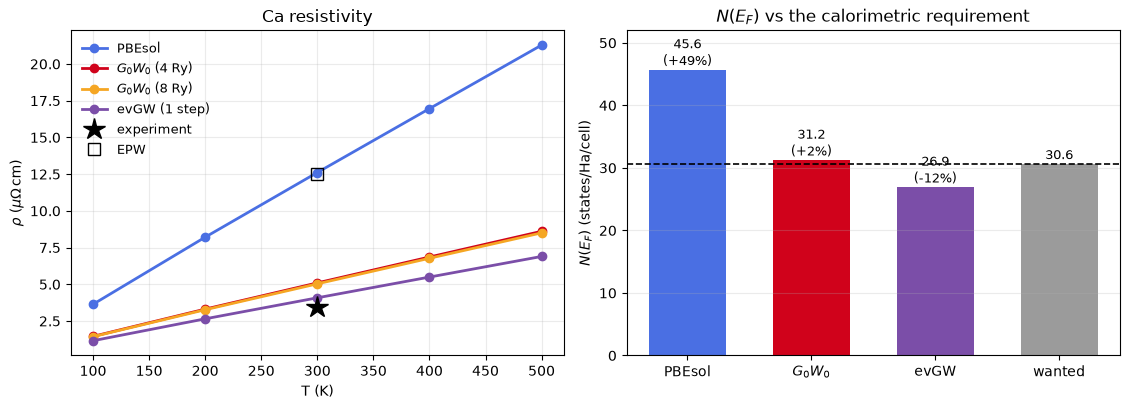

In [6]:
row = {t: r for t, r in zip(tags, tab)}
fig, ax = plt.subplots(1, 2, figsize=(11.4, 4.2))
T = g['T']
for tg, lab, c in (('DFT', 'PBEsol', '#4A6FE3'),
                   ('ppa_ng4_nb80', r'$G_0W_0$ (4 Ry)', '#D0021B'),
                   ('ppa_ng8_nb80', r'$G_0W_0$ (8 Ry)', '#F5A623'),
                   ('evgw_ng4', r'evGW (1 step)', '#7B4EA8')):
    ax[0].plot(T, g[f'rho_{tg}'], 'o-', lw=2, ms=6, color=c, label=lab)
ax[0].plot(300., 1e2/EXP, 'k*', ms=16, label='experiment')
ax[0].plot(300., 1e2/EPW48, 'ks', ms=8, mfc='none', label='EPW')
ax[0].set_xlabel('T (K)'); ax[0].set_ylabel(r'$\rho$ ($\mu\Omega\,$cm)')
ax[0].set_title('Ca resistivity'); ax[0].legend(frameon=False, fontsize=9)
ax[0].grid(alpha=.25)

# N(E_F) against a target that no transport quantity was fitted to: G0W0 lands on
# it, one more iteration walks past it.
names = ['PBEsol', r'$G_0W_0$', 'evGW', 'wanted']
vals = [row['DFT'][1], row['ppa_ng4_nb80'][1], row['evgw_ng4'][1], N_needed]
cols = ['#4A6FE3', '#D0021B', '#7B4EA8', '#9B9B9B']
ax[1].bar(names, vals, color=cols, width=.62)
ax[1].axhline(N_needed, ls='--', lw=1.2, color='k')
ax[1].set_ylabel(r'$N(E_F)$ (states/Ha/cell)')
ax[1].set_title(r'$N(E_F)$ vs the calorimetric requirement')
for i, v in enumerate(vals):
    d = 100 * (v / N_needed - 1)
    lab = f'{v:.1f}' if names[i] == 'wanted' else f'{v:.1f}\n({d:+.0f}%)'
    ax[1].text(i, v + .8, lab, ha='center', fontsize=9.5)
ax[1].set_ylim(0, 52)
ax[1].grid(alpha=.25, axis='y')
plt.tight_layout(); plt.show()

## What the factor 3.63 was made of

| term | size | how it was established |
|---|---|---|
| **waw vs EPW machinery** | **1.008×** | agreement on identical inputs, once $\mathbf q$ is converged |
| DFT $N(E_F)$ too high | **2.47×** | removed by $G_0W_0$; target set independently by $\gamma$ |
| residual | **1.46×** | unexplained; anharmonicity is bounded at 20–40% |

The residual is quoted against $G_0W_0$. evGW would put it at 1.18×, but reaches
that by placing $N(E_F)$ 12% below what the measured specific heat allows, so the
smaller number is not the better one.

**Why the published $GW$ bandwidths do not settle this.** Friedrich *et al.* find
$GW$ changes Ca's *occupied* bandwidth by 1% (1.62 → 1.64 eV), which might suggest
$GW$ is irrelevant here. It is not: an occupied-bandwidth metric is blind to the
position of the **empty 3d** manifold, and that is what moves. Both quantities are
visible in the numbers above — the $\Gamma$ band minimum shifts by only $+0.16$ eV
while $N(E_F)$ drops 32%. Any literature comparison used to judge $GW$'s
importance for a transport quantity has to be a comparison of states at $E_F$.

**Why "self-consistency moves it further" is not a reason to expect improvement.**
The same reference estimates that $G_0W_0$ recovers about half of the QSGW
correction in simple metals, and one evGW step here does move $N(E_F)$ further, 31.2
→ 26.9. That is a statement about magnitude only. Whether *further* means *better*
is decided by the external constraint, and here it means worse.

**What remains open.**

* **Vertex corrections.** The evGW overshoot is the signature of rebuilding $W$
  from widened energies without a compensating vertex. QSGW or $GW\Gamma$ is the
  principled test of whether $G_0W_0$'s landing on 30.6 reflects cancellation or
  coincidence.
* $Z$ ranges **0.15–0.74** across the three runs. Applying $GW$ as a rigid
  eigenvalue shift is on thin ice where $Z \approx 0.15$, and that has not been
  propagated into the transport.
* The plasmon-pole approximation is not validated for this metal — the 8 Ry run's
  $Z = 1.58$ shows it can fail here — and a real-axis calculation is the proper
  check.
* The residual 1.46× is the right size for anharmonicity, which is absent from
  both codes. SSCHA would be the principled route, and Ca is a good candidate,
  being above $\Theta_D$ at 300 K — though the absence of any near-zero mode
  bounds how much it can deliver.